In [3]:
import os
import torch
import yaml
from datasets_local import (
    BrudexDataModule,
    ScenarioGenerationConfig,
    BrudexConfig,
)
from utilities import STFTtransform
from pathlib import Path

# --- Add this section to teach PyYAML about custom tags like !range ---
def tuple_constructor(loader: yaml.SafeLoader, node: yaml.nodes.Node) -> tuple:
    """Constructs a tuple, ensuring the node is a sequence."""
    if not isinstance(node, yaml.nodes.SequenceNode):
        raise yaml.constructor.ConstructorError(
            "expected a sequence node, but found %s" % type(node)
        )
    return tuple(loader.construct_sequence(node))


yaml.add_constructor("!tuple", tuple_constructor, Loader=yaml.SafeLoader)
yaml.add_constructor("!range", tuple_constructor, Loader=yaml.SafeLoader)
# --- End of section ---





EXP_TYPE = "deactivation"  # "main_exp", "seglen", "deactivation"
EXP_COLLECTION = "J1_BXLS_" + EXP_TYPE  # Change this to switch experiments
DEBUG = False
RESET = False  # Whether to reset dataset generation
DATA_GEN_ONLY = False  # If True, only generate data and training and test SAD model, but not RTF model

exp_collection_paths = {
    "J1_BXLS_main_exp": {
        "dataset_config": "configs/datasets/J1_dataset_main_exp.yaml",
        "ebop_algorithm_config": "configs/algorithms/ebop.yaml",
        "framework_config": "configs/J1_framework_main_exp.yaml",
    },  # --- Standard GPU 0 ---
    "J1_BXLS_seglen": {
        "dataset_config": "configs/datasets/J1_dataset_seglen.yaml",
        "ebop_algorithm_config": "configs/algorithms/J1_ebop_seglen.yaml",
        "framework_config": "configs/J1_framework_seglen.yaml",
    },  # --- Standard GPU 1 ---
    "J1_BXLS_deactivation": {
        "dataset_config": "configs/datasets/J1_dataset_deactivation.yaml",
        "ebop_algorithm_config": "configs/algorithms/ebop.yaml",
        "framework_config": "configs/J1_framework_deactivation.yaml",
    },  # --- Standard GPU 2 ---
    "J1_BXLS_deactivation_50ms": {
        "dataset_config": "configs/datasets/J1_dataset_deactivation_50ms.yaml",
        "ebop_algorithm_config": "configs/algorithms/J1_ebop_deactivation_50ms.yaml",
        "framework_config": "configs/J1_framework_deactivation_50ms.yaml",
    },  # --- Standard GPU 2 ---
}

torch.set_float32_matmul_precision("highest")
torch.autograd.set_detect_anomaly(True)

# Get the directory of the current script to build robust paths
project_root = Path("/data4/Henri/j3/framewiseSpeakerCounting/src")

# Load configuration from the YAML files using absolute paths
dataset_config_path = os.path.join(
    project_root, exp_collection_paths[EXP_COLLECTION]["dataset_config"]
)
ebop_algorithm_config_path = os.path.join(
    project_root, exp_collection_paths[EXP_COLLECTION]["ebop_algorithm_config"]
)
framework_config_path = os.path.join(
    project_root, exp_collection_paths[EXP_COLLECTION]["framework_config"]
)
config = {}
with open(dataset_config_path, "r") as f:
    config["dataset"] = yaml.safe_load(f)
with open(ebop_algorithm_config_path, "r") as f:
    config["ebop_algorithm"] = yaml.safe_load(f)
with open(framework_config_path, "r") as f:
    config["framework"] = yaml.safe_load(f)

if EXP_TYPE == "seglen":
    config["framework"]["wandbproject"] = (
        config["framework"]["wandbproject"]
        + "_"
        + str(config["ebop_algorithm"]["smoothing_time_constant"])
    )
if DEBUG:  # --- Standard GPU 3 ---
    print(
        "Running in DEBUG mode: Reducing dataset size and epochs for quick testing."
    )
    # Reduce number of scenarios for quick debugging
    config["dataset"]["id"] = config["dataset"]["id"] + "_debug"
    config["dataset"]["num_scenarios"] = [4, 4, 4]  # train, val, test
    config["framework"]["sad_devices"] = [0]
    config["framework"]["sad_batch_size"] = 2
    config["framework"]["sad_max_epochs"] = 2
    config["framework"]["rtf_devices"] = [0]
    config["framework"]["rtf_batch_size"] = 2
    config["framework"]["wandbproject"] = (
        config["framework"]["wandbproject"] + "_debug"
    )
if DATA_GEN_ONLY:
    config["framework"]["wandbproject"] = (
        config["framework"]["wandbproject"] + "_data_gen"
    )

stft_transform = STFTtransform(
    frame_length=config["ebop_algorithm"]["frame_length"],
    frame_shift=config["ebop_algorithm"]["frame_shift"],
    sampling_frequency=config["ebop_algorithm"]["sampling_frequency"],
    window_type=config["ebop_algorithm"]["window_type"],
)

# --- Prepare Shared Config Objects ---
scenario_config = ScenarioGenerationConfig(
    max_sources=config["dataset"]["max_sources"],
    signal_lengths=config["dataset"]["signal_lengths"],
    initial_noise_only_duration=config["dataset"]["initial_noise_only_duration"],
    snrs=config["dataset"]["snrs"],
    source_power_range=config["dataset"]["source_power_range"],
    time_between_events=config["dataset"]["time_between_events"],
    fix_seglen=config["dataset"].get("fix_seglen", False),
    activations_only=config["dataset"]["activations_only"],
    remove_silence=config["dataset"]["remove_silence"],
    neglect_silence4oracle_sa=config["dataset"]["neglect_silence4oracle_sa"],
    bridge_clean_speech_gaps=config["dataset"]["bridge_clean_speech_gaps"],
    vad_threshold2define_oracle=config["dataset"]["vad_threshold2define_oracle"],
    vad_threshold2select_clean_speech=config["dataset"][
        "vad_threshold2select_clean_speech"
    ],
)

brudex_config = BrudexConfig(
    reverb_conditions=config["dataset"]["reverb_conditions"],
    microphone_arrays=config["dataset"]["microphone_arrays"],
    noise_types=config["dataset"]["noise_types"],
    doas=config["dataset"]["doas"],
)

# Instantiate DataModule (Specific to this feature extractor)
dm = BrudexDataModule(
    id=config["dataset"]["id"],
    batch_size=config["framework"]["sad_batch_size"],
    num_workers=config["framework"]["sad_num_workers"],
    num_scenarios=config["dataset"]["num_scenarios"],
    transform=stft_transform,
    sampling_frequency=config["ebop_algorithm"]["sampling_frequency"],
    generation_config=scenario_config,
    brudex_config=brudex_config,
    clean_speech_databases=config["dataset"]["clean_speech_databases"],
    feature_extractor=None,  # Using stft features
    seed=config["dataset"]["seed"],
    # acc_device=torch.device(
    #     "cuda:" + str(config["framework"]["sad_devices"][0])
    # ),  # torch.device("cuda:" + str(config["framework"]["sad_devices"][0])),
    acc_device=config["framework"]["datagen_acc_device"],
    reset=RESET,
)

dm.prepare_data()
dm.setup(stage="test")
    
    
    
    

Found implementation for clean speech database: Librispeech
LibrispeechDatabase initialized to use splits: ['train-clean-360', 'dev-clean', 'test-clean']
Found 12 RIR .mat files to consider.
Found 2 noise .mat files to consider.
Brudex Data Module Parameters:
  Batch Size: 10
  Num Workers: 0
  Num Scenarios: [1500, 150, 750]
  STFTtransform Parameters:
    Frame Length: 0.064 s
    Frame Shift: 0.016 s
    Sampling Frequency: 16000 Hz
    Window Type: sqrt-hann
    NFFT: 1024 samples
    Hop Length: 256 samples
  Sampling Frequency: 16000 [Hz]
  Max Sources: 3
  Signal Lengths: 60.0 [s]
  Initial Noise Only Duration: (0.5, 5.0) [s]
  Reverb Times: ['low'] [ms]
  Microphone Arrays: ['BTE_IE']
  Train Noise Types: ['babble', 'cafeteria']
  Val Noise Types: ['babble', 'cafeteria']
  Test Noise Types: ['babble', 'cafeteria']
  SNRs: [0, 5, 10, 15] [dB]
  Clean Speech Databases: ['Librispeech']
  Train DOAs: [-150, -120, -90, -60, -30, 0, 30, 60, 90, 120, 150, 180] [°]
  Val DOAs: [-150, -

Pre-processing BRUDEX RIRs: 100%|██████████| 12/12 [00:00<00:00, 21281.88it/s]



Starting BRUDEX noise .mat to .pt pre-processing...


Pre-processing BRUDEX Noises: 100%|██████████| 2/2 [00:00<00:00, 9974.56it/s]
Seed set to 777
Seed set to 777



--- Starting scenario pre-computation ---
Scenarios will be saved to: /data4/Henri/j3/framewiseSpeakerCounting/databases/precomputed/J1_BXLS_deactivation
Loading cached clips from: /data4/Henri/j3/framewiseSpeakerCounting/databases/librispeech/train-clean-360/clean_speech_clips.pt
Loaded 9389 virtual clips for 919 speakers from cache.


...

Loading cached clips from: /data4/Henri/j3/framewiseSpeakerCounting/databases/librispeech/dev-clean/clean_speech_clips.pt
Loaded 112 virtual clips for 40 speakers from cache.


Constructing 150 scenarios for J1_BXLS_deactivation_val_generator: 100%|██████████| 150/150 [00:00<00:00, 12356.05it/s]
Pre-computing val scenarios: 100%|██████████| 150/150 [00:00<00:00, 88599.58it/s]
Seed set to 779


Loading cached clips from: /data4/Henri/j3/framewiseSpeakerCounting/databases/librispeech/test-clean/clean_speech_clips.pt
Loaded 118 virtual clips for 40 speakers from cache.


Constructing 750 scenarios for J1_BXLS_deactivation_test_generator: 100%|██████████| 750/750 [00:00<00:00, 15814.04it/s]
Pre-computing test scenarios: 100%|██████████| 750/750 [00:00<00:00, 98181.27it/s]


Data preparation finished.
No feature extractor defined. Loading raw audio.
Initialized dataset with 750 files from 1 directories.


SNR: 0 dB


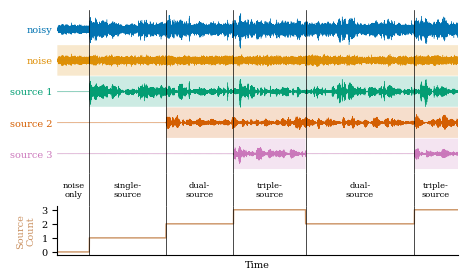

Saved scenario plot to: /data4/Henri/j3/framewiseSpeakerCounting/src/plot_scripts/scenario_16.pdf
Also saved scenario plot to: /data4/Henri/j3/framewiseSpeakerCounting/documents/Journal2/Springer_version/sn-article-template/figures/Plots/revision_caused_by_J1_reviews/scenario_plot.pdf


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns # Ensure seaborn is imported

# --- USER SETTINGS ---
REMOVE_X_TICKS = True # Set to True to remove x-axis ticks/labels from the bottom plot
# ---------------------

def plot_scenario(scenario, fs=16000, x_limit=None, remove_x_ticks=False, force_snr=None, waveform_spacing=1.5, subplot_hspace=0.0):
   
    # --- Config for Paper Application ---
    textwidth_pt = 372.0 # for springer one column, for TASLP two column 252.0
    inch_per_pt = 1.0 / 72
    fig_width_in = textwidth_pt * inch_per_pt 
    
    # Height = Golden Ratio * Width
    # Slightly tune height for better aspect
    golden_ratio = (np.sqrt(5) - 1.0) / 2.0 
    fig_height_in = fig_width_in * golden_ratio #* 1.3 
    
    # Font settings
    general_font_size = 7
    plt.rcParams.update({
        'font.size': general_font_size,          
        'axes.labelsize': general_font_size,
        'axes.titlesize': general_font_size,
        'legend.fontsize': general_font_size,
        'xtick.labelsize': general_font_size,
        'ytick.labelsize': general_font_size,
        'figure.titlesize': general_font_size,
        'font.family': 'serif', 
    })

    # Get Seaborn Colorblind Palette
    palette = sns.color_palette("colorblind", n_colors=10)
    # 0: Blue, 1: Orange, 2: Green, 3: Red, 4: Purple, 5: Brown, 6: Pink, 7: Gray, 8: Yellow, 9: Cyan
    
    # Extract Metadata
    meta = scenario['meta']
    references = meta['references']
    sad_samples = meta['sad_samples'] 
    
    # 1. Gather all component signals 
    component_keys = list(references.keys())
    
    # if force_snr is not None, adjust the power of the noise component to achieve the desired SNR using the
    if force_snr is not None and 'noise' in component_keys:
        noise_signal = references['noise']
        current_snr = scenario['meta']['scenario_params']['snr']
        scaling_factor = 10 ** ((current_snr - force_snr) / 20)
        references['noise'] = noise_signal * scaling_factor
    
    # Separate noise and speakers
    noise_key = 'noise' if 'noise' in component_keys else None
    speaker_keys = [k for k in component_keys if k != 'noise']
    
    # Sort speakers by their FIRST activation time
    speaker_start_times = []
    for k in speaker_keys:
        vad = sad_samples[k]
        if hasattr(vad, "numpy"): vad = vad.cpu().numpy()
        active_indices = np.where(vad > 0.5)[0]
        first_active = active_indices[0] if len(active_indices) > 0 else float('inf')
        speaker_start_times.append((k, first_active))
    
    speaker_start_times.sort(key=lambda x: x[1])
    sorted_speaker_keys = [x[0] for x in speaker_start_times]
    
    # 2. Construct signals
    plot_signals = {}
    plot_vads = {}
    
    # Mixture
    first_ref = references[component_keys[0]]
    if hasattr(first_ref, "numpy"):
        mixture = torch.zeros_like(first_ref)
        for k in component_keys: mixture += references[k]
        mixture = mixture.cpu().numpy()
    else:
        mixture = np.zeros_like(first_ref)
        for k in component_keys: mixture += references[k]
            
    if mixture.ndim == 2: mixture = mixture[0]
    
    ordered_labels = ['noisy']
    plot_signals['noisy'] = mixture
    plot_vads['noisy'] = None 
    
    if noise_key:
        n_sig = references[noise_key]
        if hasattr(n_sig, "numpy"): n_sig = n_sig.cpu().numpy()
        if n_sig.ndim == 2: n_sig = n_sig[0]
        plot_signals['noise'] = n_sig
        
        n_vad = sad_samples[noise_key]
        if hasattr(n_vad, "numpy"): n_vad = n_vad.cpu().numpy()
        plot_vads['noise'] = n_vad
        ordered_labels.append('noise')
        
    for i, k in enumerate(sorted_speaker_keys):
        s_sig = references[k]
        if hasattr(s_sig, "numpy"): s_sig = s_sig.cpu().numpy()
        if s_sig.ndim == 2: s_sig = s_sig[0]
        
        label = f"source {i+1}"
        plot_signals[label] = s_sig
        
        s_vad = sad_samples[k]
        if hasattr(s_vad, "numpy"): s_vad = s_vad.cpu().numpy()
        plot_vads[label] = s_vad
        ordered_labels.append(label)
        
    # Assign colors to signals
    # We use limits of palette length, cycling if needed
    signal_colors = {}
    for i, label in enumerate(ordered_labels):
        signal_colors[label] = palette[i % len(palette)]

    # 3. Global Scaling
    global_max_abs = 0.0
    for label in ordered_labels:
        global_max_abs = max(global_max_abs, np.max(np.abs(plot_signals[label])))
    
    spacing_step = waveform_spacing
    target_peak = 0.95
    if global_max_abs > 0:
        scale_factor = target_peak / global_max_abs
    else:
        scale_factor = 1.0

    # 4. Plotting Setup
    num_signals = len(ordered_labels)
    num_samples = mixture.shape[-1]
    time = np.arange(num_samples) / fs
    max_time = time[-1]
    plot_limit = x_limit if x_limit is not None else max_time
    # Ensure we don't exceed actual duration 
    if plot_limit > max_time: plot_limit = max_time

    # Calculate Total Active Speakers
    total_active_speakers = np.zeros(num_samples, dtype=int)
    for k in sorted_speaker_keys:
        vad = sad_samples[k]
        if hasattr(vad, "numpy"): vad = vad.cpu().numpy()
        total_active_speakers += (vad > 0.5).astype(int)

    # Create figure
    fig = plt.figure(figsize=(fig_width_in, fig_height_in))
    # Layout: Top (Waveforms) | Middle (Segments Labels) | Bottom (Count)
    gs = fig.add_gridspec(3, 1, height_ratios=[5, 1, 1.5], hspace=subplot_hspace)
    
    ax_waves = fig.add_subplot(gs[0])
    ax_seg   = fig.add_subplot(gs[1], sharex=ax_waves)
    ax_count = fig.add_subplot(gs[2], sharex=ax_waves)

    # --- Plot Waveforms (Top) ---
    yticks = []
    yticklabels = []
    
    for i, label in enumerate(ordered_labels):
        y_center = (num_signals - 1 - i) * spacing_step
        signal_scaled = plot_signals[label] * scale_factor
        vad = plot_vads[label]
        
        current_color = signal_colors[label]
        
        step = 1
        ax_waves.plot(time[::step], signal_scaled[::step] + y_center, color=current_color, linewidth=0.3, rasterized=False)
        
        if vad is not None:
            if label.startswith("source"):
                # already counted above
                pass
            is_active = vad > 0.5
            limit = spacing_step / 2.0 * 0.98 
            # Light version using alpha
            ax_waves.fill_between(time, y_center - limit, y_center + limit, 
                                  where=is_active, color=current_color, alpha=0.2, linewidth=0, rasterized=True)
            
        yticks.append(y_center)
        yticklabels.append(label)
        # Reference Line
        ax_waves.axhline(y_center, color='gray', linestyle=':', linewidth=0.3, alpha=0.5)

    ax_waves.set_yticks(yticks)
    ax_waves.set_yticklabels(yticklabels, fontsize=7)
    
    # Colorize y-labels
    for tick_label, label_text in zip(ax_waves.get_yticklabels(), yticklabels):
        tick_label.set_color(signal_colors[label_text])
        
    ax_waves.tick_params(axis='y', length=0)
    ax_waves.tick_params(axis='x', length=0, labelbottom=False) 
    ax_waves.set_ylim([-spacing_step/2 - 0.2, (num_signals - 1) * spacing_step + spacing_step/2 + 0.2])
    
    # Hide spines (waveforms)
    ax_waves.spines['top'].set_visible(False)
    ax_waves.spines['right'].set_visible(False)
    ax_waves.spines['left'].set_visible(False)
    ax_waves.spines['bottom'].set_visible(False)

    # --- Plot Count (Bottom) ---
    count_color = palette[5] # 6th color
    
    ax_count.plot(time, total_active_speakers, color=count_color, linewidth=1.0)
    
    ax_count.set_ylabel("Source\nCount", fontsize=7, color=count_color)
    ax_count.tick_params(axis='y', )#colors=count_color)
    
    if remove_x_ticks:
        ax_count.set_xlabel("Time", fontsize=7) 
        ax_count.tick_params(axis='x', length=0, labelbottom=False)
    else:
        ax_count.set_xlabel("Time [s]", fontsize=7)
    
    max_count = np.max(total_active_speakers) if len(total_active_speakers) > 0 else 3
    ax_count.set_yticks(range(max_count + 1)) 
    ax_count.set_ylim([-0.25, max_count + 0.25])
    # ax_count.grid(True, alpha=0.3, linewidth=0.3)
    
    # Hide spines (bottom)
    ax_count.spines['top'].set_visible(False)
    ax_count.spines['right'].set_visible(False)
    
    # Set X Limit for all
    ax_count.set_xlim([0, plot_limit])

    # --- Plot Segments (Middle) ---
    # Find transitions
    d = np.diff(total_active_speakers)
    change_idx = np.where(d != 0)[0] + 1
    boundaries = np.concatenate(([0], change_idx, [num_samples]))
    
    def get_label(n):
        if n == 0: return "noise\nonly"
        if n == 1: return "single-\nsource"
        if n == 2: return "dual-\nsource"
        if n == 3: return "triple-\nsource"
        return f"{n}src"

    for i in range(len(boundaries) - 1):
        start_idx = boundaries[i]
        end_idx = boundaries[i+1]
        start_t = time[start_idx]
        end_t = time[end_idx-1] if end_idx < num_samples else time[-1]
        
        if start_t > plot_limit: continue
        
        count_val = total_active_speakers[start_idx]
        seg_label = get_label(count_val)
        
        # Vertical Separator Line - Through ALL plots
        if start_t > 0:
            for ax in [ax_waves, ax_seg, ax_count]:
                ax.axvline(start_t, color='black', linewidth=0.5, linestyle='-')

        # Label in Middle Axis
        mid_t = (start_t + min(end_t, plot_limit)) / 2
        if mid_t < plot_limit:
            ax_seg.text(mid_t, 0.5, seg_label, ha='center', va='center', fontsize=6)

    # Config Middle Axis
    ax_seg.set_yticks([])
    ax_seg.set_xlabel("") 
    ax_seg.tick_params(axis='x', length=0, labelbottom=False)
    # Hide spines (middle)
    ax_seg.spines['top'].set_visible(False)
    ax_seg.spines['right'].set_visible(False)
    ax_seg.spines['left'].set_visible(False)
    ax_seg.spines['bottom'].set_visible(False)
    ax_seg.set_facecolor('none') 




    plt.show()
    
    # Finally save the figure as pdf in the same directory as the script
    save_dir = project_root / "plot_scripts"
    save_path = save_dir / f"scenario_{index}.pdf"
    fig.savefig(save_path, bbox_inches='tight', dpi=600)
    save_path2 = "/data4/Henri/j3/framewiseSpeakerCounting/documents/Journal2/Springer_version/sn-article-template/figures/Plots/revision_caused_by_J1_reviews/scenario_plot.pdf"
    fig.savefig(save_path2, bbox_inches='tight', dpi=600)
    print(f"Saved scenario plot to: {save_path}")
    print(f"Also saved scenario plot to: {save_path2}")
    
# Execute plot
fs = config['ebop_algorithm']['sampling_frequency'] if 'config' in locals() else 16000

start_index = 0 
indexrange = [16] #range(start_index,start_index+20)
for index in indexrange:
    scenario = dm.test_ds[index]
    print(F"SNR: {scenario['meta']['scenario_params']['snr']} dB")
    plot_scenario(scenario, fs=fs, x_limit=13.7, remove_x_ticks=REMOVE_X_TICKS, force_snr=0.0, waveform_spacing=1.5, subplot_hspace=0.0)